In [1]:
# --- Imports ---
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Ready. seed =", SEED)


2025-09-11 15:52:15.335022: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757605935.359495    2484 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757605935.366939    2484 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Ready. seed = 42


In [2]:
# Cell 2: paths & basic imports (no augmentation here)

import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tqdm import tqdm

# Paths
original_dataset_dir = "/kaggle/input/potato-disease-dataset/Potato_Disease_Dataset"
augmented_dataset_dir = "/kaggle/working/augmented_dataset"
os.makedirs(augmented_dataset_dir, exist_ok=True)

# Copy άλλες κατηγορίες όπως είναι
for category in os.listdir(original_dataset_dir):
    src = os.path.join(original_dataset_dir, category)
    dst = os.path.join(augmented_dataset_dir, category)
    os.makedirs(dst, exist_ok=True)
    if category != "Potato___healthy":
        for fname in os.listdir(src):
            os.system(f"cp '{os.path.join(src,fname)}' '{dst}/'")

# Augmentation setup
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode="nearest"
)

target_augmented = 600
healthy_dir = os.path.join(original_dataset_dir, "Potato___healthy")
augmented_healthy_dir = os.path.join(augmented_dataset_dir, "Potato___healthy")
os.makedirs(augmented_healthy_dir, exist_ok=True)

healthy_images = os.listdir(healthy_dir)
n_original = len(healthy_images)
n_to_generate = target_augmented - n_original

print(f"Healthy original: {n_original} | Θα δημιουργηθούν: {n_to_generate}")

generated = 0
for img_name in tqdm(healthy_images, desc="Augmenting Healthy"):
    if generated >= n_to_generate:
        break

    img_path = os.path.join(healthy_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = np.expand_dims(img, axis=0)

    aug_iter = datagen.flow(img, batch_size=1)
    for i in range(10):
        if generated >= n_to_generate:
            break
        aug_img = next(aug_iter)[0].astype(np.uint8)
        save_path = os.path.join(augmented_healthy_dir, f"aug_{generated}.jpg")
        cv2.imwrite(save_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
        generated += 1

print(f"✅ Δημιουργήθηκαν {generated} νέες Healthy εικόνες")



Healthy original: 152 | Θα δημιουργηθούν: 448


Augmenting Healthy:  30%|██▉       | 45/152 [00:07<00:17,  6.08it/s]

✅ Δημιουργήθηκαν 448 νέες Healthy εικόνες


In [3]:
# Cell 3: split first, then augment ONLY train/healthy (με περισσότερα healthy)

import shutil

output_split_dir = "/kaggle/working/Potato_Disease_Dataset_Split"
if os.path.exists(output_split_dir):
    shutil.rmtree(output_split_dir)
os.makedirs(output_split_dir, exist_ok=True)

train_split, val_split, test_split = 0.7, 0.15, 0.15

split_counts = {"train": {}, "val": {}, "test": {}}

for category in os.listdir(augmented_dataset_dir):
    category_dir = os.path.join(augmented_dataset_dir, category)
    images = os.listdir(category_dir)
    random.shuffle(images)

    n_total = len(images)
    n_train = int(train_split * n_total)
    n_val = int(val_split * n_total)
    n_test = n_total - n_train - n_val

    # Ελάχιστο 1 δείγμα στο test για κάθε κλάση
    if n_test == 0:
        n_test = 1
        n_train -= 1

    train_files = images[:n_train]
    val_files = images[n_train:n_train + n_val]
    test_files = images[n_train + n_val:]

    for split, files in zip(["train", "val", "test"], [train_files, val_files, test_files]):
        dest = os.path.join(output_split_dir, split, category)
        os.makedirs(dest, exist_ok=True)
        for fname in files:
            shutil.copy(os.path.join(category_dir, fname), dest)
        split_counts[split][category] = len(files)

print("✅ Split ολοκληρώθηκε με seed =", SEED)
print("train", split_counts["train"])
print("val", split_counts["val"])
print("test", split_counts["test"])


✅ Split ολοκληρώθηκε με seed = 42
train {'Potato___Late_blight': 700, 'Potato___healthy': 313, 'Potato___Early_blight': 700}
val {'Potato___Late_blight': 150, 'Potato___healthy': 67, 'Potato___Early_blight': 150}
test {'Potato___Late_blight': 150, 'Potato___healthy': 68, 'Potato___Early_blight': 150}


In [4]:
# Cell 4: verify class counts after augmentation & build generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_WIDTH, IMG_HEIGHT, BATCH_SIZE = 224, 224, 32

train_dir = os.path.join(output_split_dir, "train")
val_dir = os.path.join(output_split_dir, "val")
test_dir = os.path.join(output_split_dir, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    shear_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_WIDTH, IMG_HEIGHT), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True, seed=SEED
)
validation_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=(IMG_WIDTH, IMG_HEIGHT), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False, seed=SEED
)
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_WIDTH, IMG_HEIGHT), batch_size=1,
    class_mode="categorical", shuffle=False, seed=SEED
)

NUM_CLASSES = train_generator.num_classes
print("✅ Generators έτοιμοι. Classes:", train_generator.class_indices)


Found 1713 images belonging to 3 classes.
Found 367 images belonging to 3 classes.
Found 368 images belonging to 3 classes.
✅ Generators έτοιμοι. Classes: {'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}


In [9]:
# Cell 5: training model on the split dataset (focal loss χωρίς alpha)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

# Class weights
train_labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights))
print("✅ Class Weights:", class_weights)

# Focal loss
def focal_loss(gamma=2., alpha=.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return focal_loss_fixed

# Base Model
base_model = tf.keras.applications.EfficientNetV2S(
    include_top=False, weights="imagenet", input_shape=(224, 224, 3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(1e-4), loss=focal_loss(), metrics=["accuracy"])

# Callbacks
checkpoint_path = "./best_model.keras"
checkpoint = ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True, mode="max")
early_stop = EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=4, verbose=1, min_lr=1e-7)

# Training
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, lr_reduce]
)

# Fine-tuning
base_model.trainable = True
model.compile(optimizer=Adam(5e-6), loss=focal_loss(), metrics=["accuracy"])
history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, lr_reduce]
)

print("✅ Εκπαίδευση ολοκληρώθηκε")




✅ Class Weights: {0: 0.8157142857142857, 1: 0.8157142857142857, 2: 1.8242811501597445}
Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.3188 - loss: 0.1277 - val_accuracy: 0.4360 - val_loss: 0.1061 - learning_rate: 1.0000e-04
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 420ms/step - accuracy: 0.4481 - loss: 0.1142 - val_accuracy: 0.5858 - val_loss: 0.0994 - learning_rate: 1.0000e-04
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 415ms/step - accuracy: 0.5175 - loss: 0.1113 - val_accuracy: 0.6294 - val_loss: 0.0962 - learning_rate: 1.0000e-04
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 388ms/step - accuracy: 0.5611 - loss: 0.1057 - val_accuracy: 0.6294 - val_loss: 0.0944 - learning_rate: 1.0000e-04
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 428ms/step - accuracy: 0.5374 - loss: 0.1097 - val_accuracy: 0.6376 - val_loss: 0.0926 - learning_rate: 1.0000e-04
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 426ms/step - accuracy: 0.5691 - loss: 0.1022 - val_accuracy: 0.6431 - val_loss: 0.0912 -

368/368 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9544 - loss: 0.0163

✅ Test Accuracy: 0.9266 | Loss: 0.0236
368/368 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step

📊 Classification Report:
                       precision    recall  f1-score   support

Potato___Early_blight     0.9728    0.9533    0.9630       150
 Potato___Late_blight     0.8655    0.9867    0.9221       150
     Potato___healthy     1.0000    0.7353    0.8475        68

             accuracy                         0.9266       368
            macro avg     0.9461    0.8918    0.9108       368
         weighted avg     0.9341    0.9266    0.9250       368



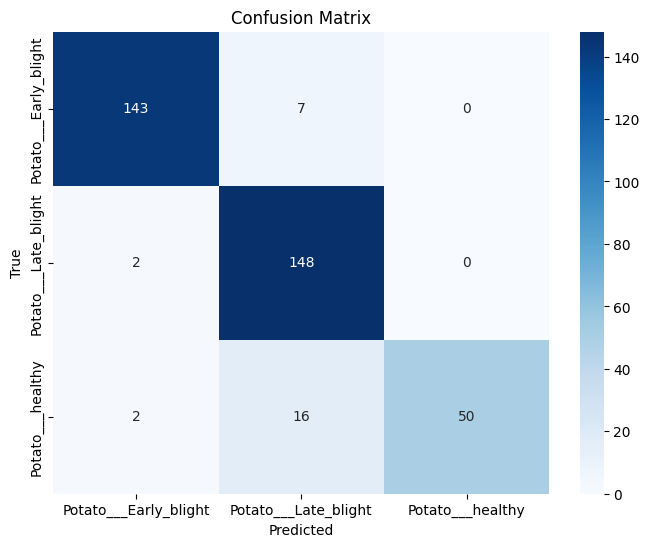

In [10]:
# Cell 6: evaluation, classification report, confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model = tf.keras.models.load_model(checkpoint_path, custom_objects={"focal_loss_fixed": focal_loss()})

loss, acc = model.evaluate(test_generator, steps=test_generator.samples)
print(f"\n✅ Test Accuracy: {acc:.4f} | Loss: {loss:.4f}")

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
predictions = model.predict(test_generator, steps=test_generator.samples, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

print("\n📊 Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels, digits=4))

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


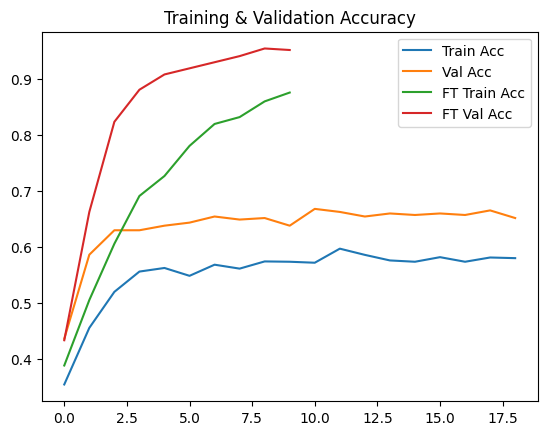

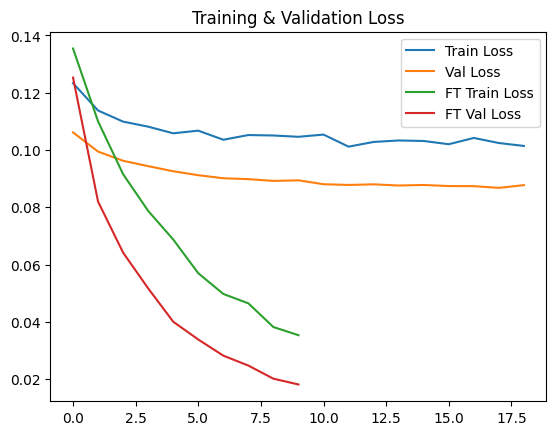

In [11]:
# Cell 7: save plots
# Accuracy curves
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.plot(history_finetune.history['accuracy'], label='FT Train Acc')
plt.plot(history_finetune.history['val_accuracy'], label='FT Val Acc')
plt.legend()
plt.title("Training & Validation Accuracy")
plt.show()

# Loss curves
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.plot(history_finetune.history['loss'], label='FT Train Loss')
plt.plot(history_finetune.history['val_loss'], label='FT Val Loss')
plt.legend()
plt.title("Training & Validation Loss")
plt.show()

